# Analyse PE samples review
Notebook to analyse the PE samples. Starts by reading in the correct config and backend files from the correct sampling directory. Then it unpacks the loglikelihood and we can assess the convergence based on the loglikelihood and the traces of the deviation for each sampled parameter. That should look like gaussian, stationary noise, otherwise the sampler has not converged yet and we need to take more samples. 

The notebook produces some plots showing the results. First two corner plots, one with and and one without the extrisic parameters. Then two plots to determine the convergence: one of the evolution of the estimated variance (=diagonal element of covariance matrix) for each parameter, and one with the Gelman-Rubin criterion for convergence. 

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.size'] = 14

from src.io import param_load
from src.analysis import (
    sampled_params_from_config,
    load_samples,
    load_samples_named,
    plot_log_like,
    cut_samples_autocorr,
    filter_lost_walkers,
    corner_plot,
    plot_sky_position,
    plot_chain_convergence,
    plot_covariance_evolution,
    plot_gelman_rubin,
    plot_seaborn_diagnostics,
)

## Define samples

In [2]:
# define PE run settings
src_index = 10
inj = '1PA'
rec = '0PA'
eps = 'e-4'
addition = '' #'_amps'

# Post-processing
do_filter_lost   = False  # remove lost walkers
do_thin          = False  # thin by integrated auto-correlation time to exclude correlated samples
exclude_sky      = False  # exclude sky-angle params from the intrinsic corner plot

# Threshold for lost walker detection 
# This only applies to the cold chain
lost_lower_bound = -30.0

# Colour for this run's posterior in overlay plots
posterior_color  = 'maroon'

In [3]:
sampling_dir = f'{os.getcwd()}/scripts/sampling_data'

In [35]:
run_dir = os.path.join(sampling_dir, 'Review_test_1_inj_1PA_rec_1PA_2026-06-12_09-46-51')
print(f'Using run directory: {run_dir}')

# Find the HDF5 backend file inside
h5_files = glob.glob(os.path.join(run_dir, 'SamplingResults_*.h5'))
if not h5_files:
    raise FileNotFoundError(f'No HDF5 file found in {run_dir}')
file_path = h5_files[0]
print(f'Loading: {file_path}')

Using run directory: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/scripts/sampling_data/Review_test_1_inj_1PA_rec_1PA_2026-06-12_09-46-51
Loading: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/scripts/sampling_data/Review_test_1_inj_1PA_rec_1PA_2026-06-12_09-46-51/SamplingResults_Review_test_1_inj_1PA_rec_1PA_fixedx_I0_1.0_e0_0.0_Phi_theta0_6.13001602516006_Phi_r0_4.782381792256834_2026-06-12_09-46-51.h5


In [36]:
# new structure copies config file into the directory
conf_file = glob.glob(os.path.join(run_dir, '*.yaml'))

if not conf_file:
    raise FileNotFoundError(f'No HDF5 file found in {run_dir}')
config_file_path = conf_file[0]
config = param_load(config_file_path)

emri   = config['Injection']['EMRI']
inj_wf = config['Injection']['Waveform']
rec_wf = config['Recovery']['Waveform']

amps_toggle = config['Recovery']['Waveform']['include_1PA_amps']
evolution_primary_toggle = config['Recovery']['Waveform']['evolve_chi1']

print(f"Injection model : {inj_wf['model']}")
print(f"Recovery model  : {rec_wf['model']} \n 1PA amps {amps_toggle}, evolution primary {evolution_primary_toggle}")
print(f"Fixed params    : {config['Sampler'].get('fixed_params', [])}")
print()
print('EMRI injection parameters')
print('=' * 32)
for k, v in emri.items():
    print(f'  {k:<16} {v}')
    
print('=' * 32)
print(f'Mass-ratio m2 / m1= {emri['mu'] / emri['M']:.2e}')

Injection model : 1PAT1R
Recovery model  : 1PAT1R 
 1PA amps True, evolution primary True
Fixed params    : ['x_I0', 'e0', 'Phi_theta0', 'Phi_r0']

EMRI injection parameters
  M                4975124.504066709
  mu               99.50249008133419
  a                0.02
  p0               16.8123
  e0               0.0
  chi2             0.5
  x_I0             1.0
  d_L              0.022213015032605164
  theta_S          2.4314546363447995
  phi_S            2.757554564287996
  theta_K          2.6973649175810768
  phi_K            4.381692553882582
  Phi_phi0         0.5917337285168199
  Phi_theta0       6.13001602516006
  Phi_r0           4.782381792256834
  z                0.004999974556005059
Mass-ratio m2 / m1= 2.00e-05


In [37]:
param_names, true_vals = sampled_params_from_config(config)

print(f'Sampled parameters ({len(param_names)}):')
for name, val in zip(param_names, true_vals):
    print(f'  {name:<16} {val}')

Sampled parameters (11):
  M                5000000.0
  mu               100.0
  a                0.02
  p0               16.8123
  chi2             0.5
  d_L              0.022213015032605164
  theta_S          2.4314546363447995
  phi_S            2.757554564287996
  theta_K          2.6973649175810768
  phi_K            4.381692553882582
  Phi_phi0         0.5917337285168199


In [49]:
discard= 4500   # burn-in iterations to discard

In [50]:
# Load samples and log-likelihoods from the HDF5 backend file
samples_per_temp, reader, log_like, (N_iters, N_temps, N_walkers, N_params) = \
    load_samples(file_path, discard=discard)

print(f'Shape: {N_iters} iters  x  {N_temps} temps  x  {N_walkers} walkers  x  {N_params} params')

Shape: 679 iters  x  2 temps  x  40 walkers  x  11 params


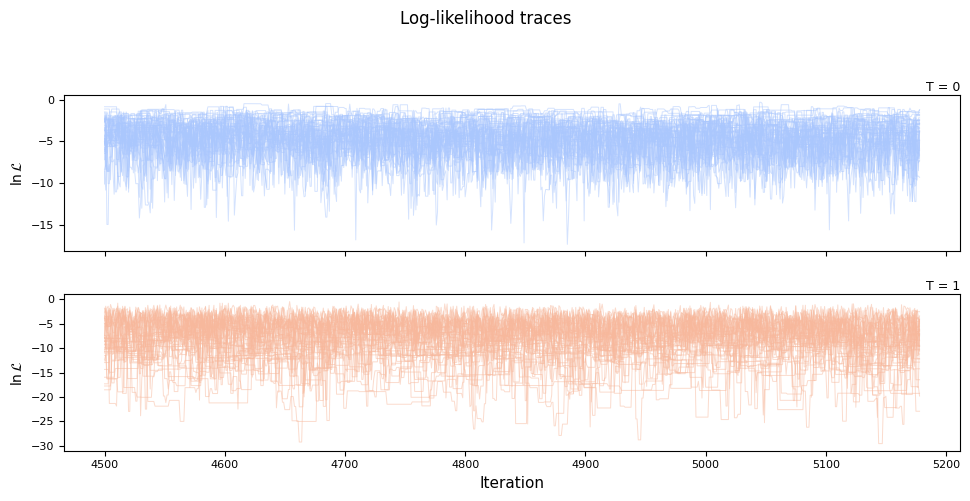

In [51]:
plot_log_like(log_like, temps=list(range(N_temps)), discard=discard)
plt.show()

Removed 0/40 lost walkers (lower_bound=-2400.0).


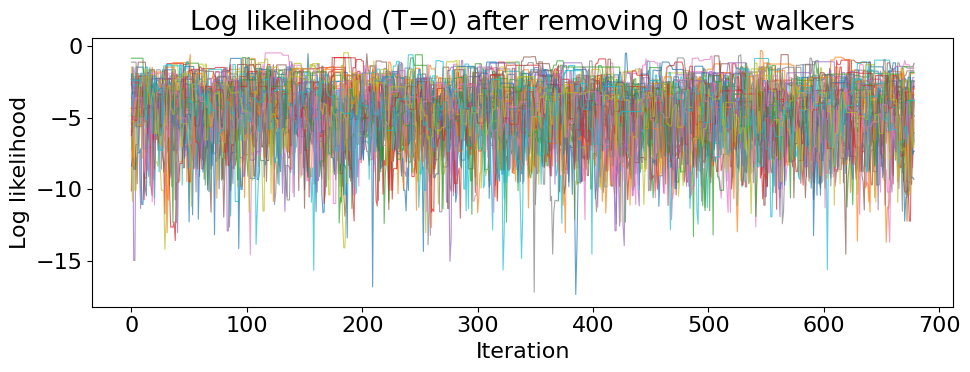

Cold chain after filtering: (27160, 11)


In [52]:
# if the lgglikelihood shows lost walkers, we filetr these out from the cold chain
do_filter_lost=True
if do_filter_lost:
    clean_samples, kept_idx, ll_clean = filter_lost_walkers(
        reader, discard=discard, lower_bound=-2400
    )
    # Replace cold-chain samples with the filtered version
    samples_per_temp[0] = clean_samples
    print(f'Cold chain after filtering: {clean_samples.shape}')
else:
    print('Skipping lost-walker filtering.')

In [53]:
if do_thin:
    samples_per_temp = cut_samples_autocorr(reader, samples_per_temp, discard=discard)
    print(f'Thinned cold chain: {samples_per_temp[0].shape}')
else:
    print('Skipping autocorrelation thinning.')

Skipping autocorrelation thinning.


### Verify chain convergence
A stable loglikelihood trace indicates that the chains have converged. However, proper convergence diagnostics are needed to confirm this. We plot the loglikelihood trace for the cold chain (T=0) to visually inspect its behavior over iterations. A stable and well-mixed trace suggests good convergence, while trends or large fluctuations point to issues with convergence.

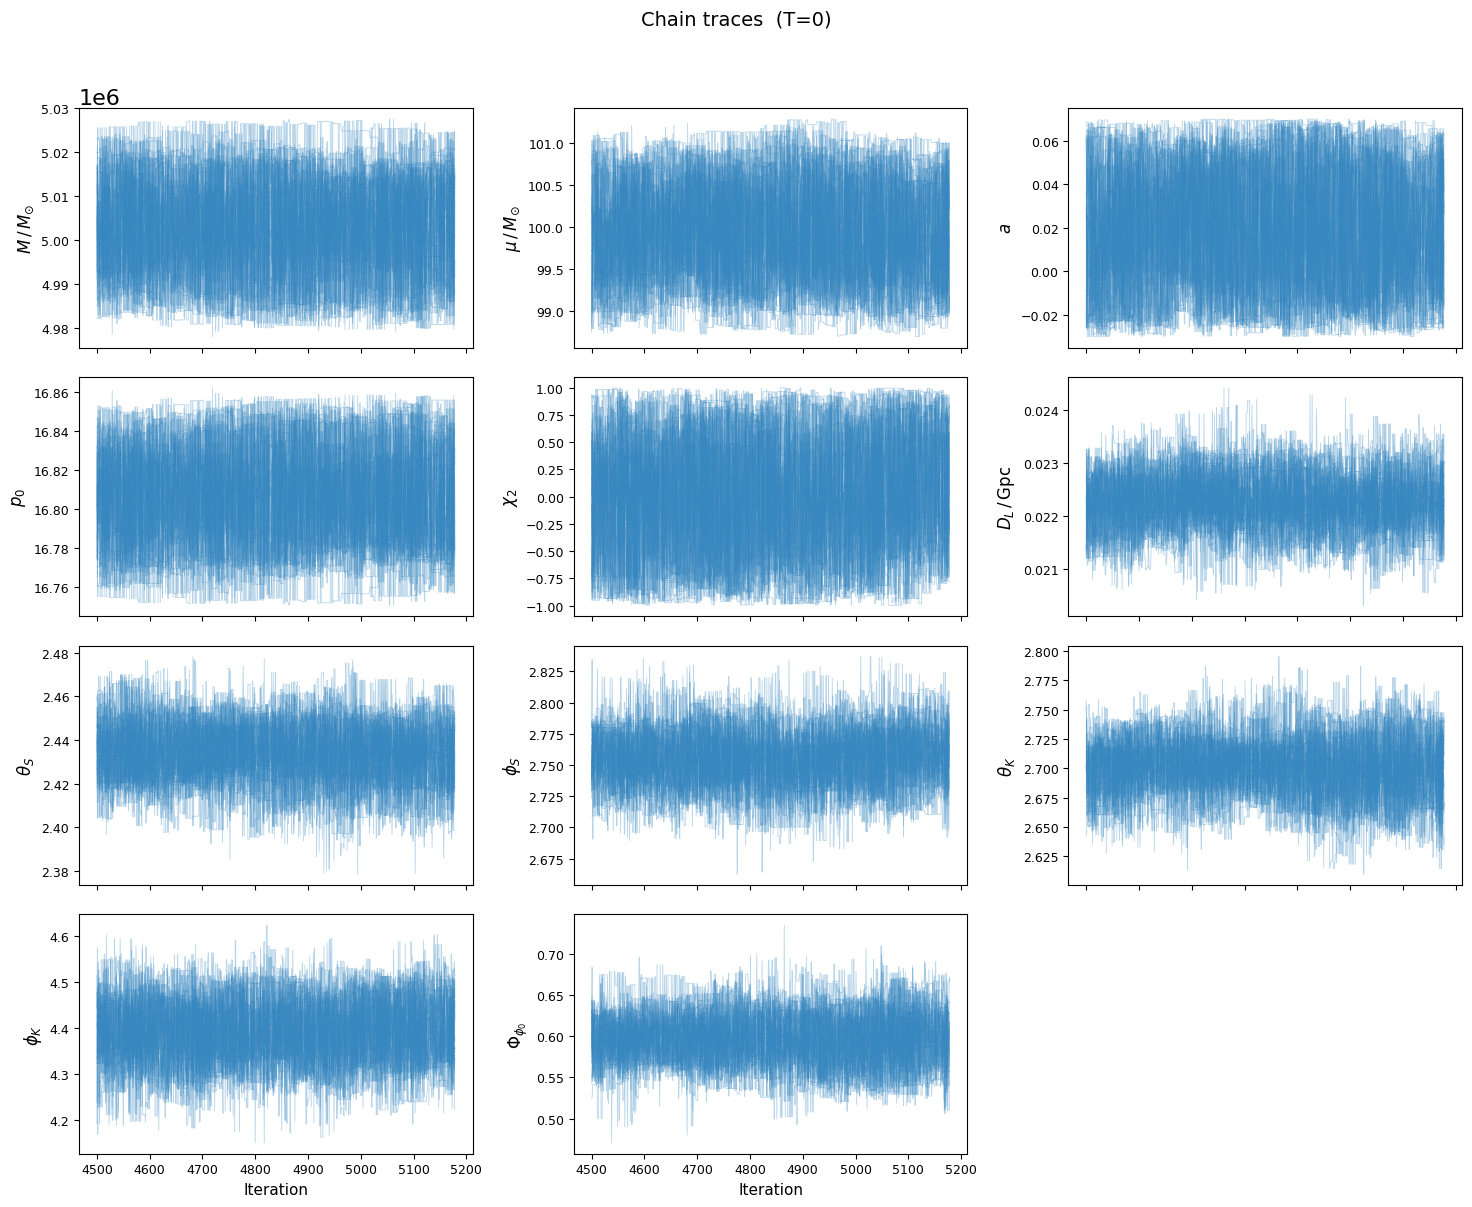

In [54]:
fig = plot_chain_convergence(
    reader, param_names,
    discard=discard, temp=0,
    # plot_name=plot_name_traces,
)

## Corner plot
Create corner plot kto inspect the posterior distributions of parameters and their correlations

In [55]:
true_vals

array([5.00000000e+06, 1.00000000e+02, 2.00000000e-02, 1.68123000e+01,
       5.00000000e-01, 2.22130150e-02, 2.43145464e+00, 2.75755456e+00,
       2.69736492e+00, 4.38169255e+00, 5.91733729e-01])

In [56]:
include_prior_bounds = True
if include_prior_bounds:
    from src.priors import build_priors

    # Match the call used by sample.py
    fixed_names = list(config['Sampler'].get('fixed_params', []) or [])
    _, bounds, _ = build_priors(
        param_names, true_vals, fixed_names,
        n=float(config['Sampler']['d']),
        use_cupy=False,                     # no GPU needed for bounds
    )
    prior_bounds = {n: bounds[k] for k, n in enumerate(param_names)}


In [57]:
prior_bounds

{'M': (np.float64(4965000.0), np.float64(5035000.0)),
 'mu': (np.float64(50.0), np.float64(150.0)),
 'a': (np.float64(-0.030000000000000002), np.float64(0.07)),
 'p0': (np.float64(11.8123), np.float64(21.8123)),
 'chi2': (-0.999, 0.999),
 'd_L': (0.001, np.float64(2.522213015032605)),
 'theta_S': (0.0, 3.141592653589793),
 'phi_S': (0.0, 6.283185307179586),
 'theta_K': (0.0, 3.141592653589793),
 'phi_K': (0.0, 6.283185307179586),
 'Phi_phi0': (0.0, 6.283185307179586)}

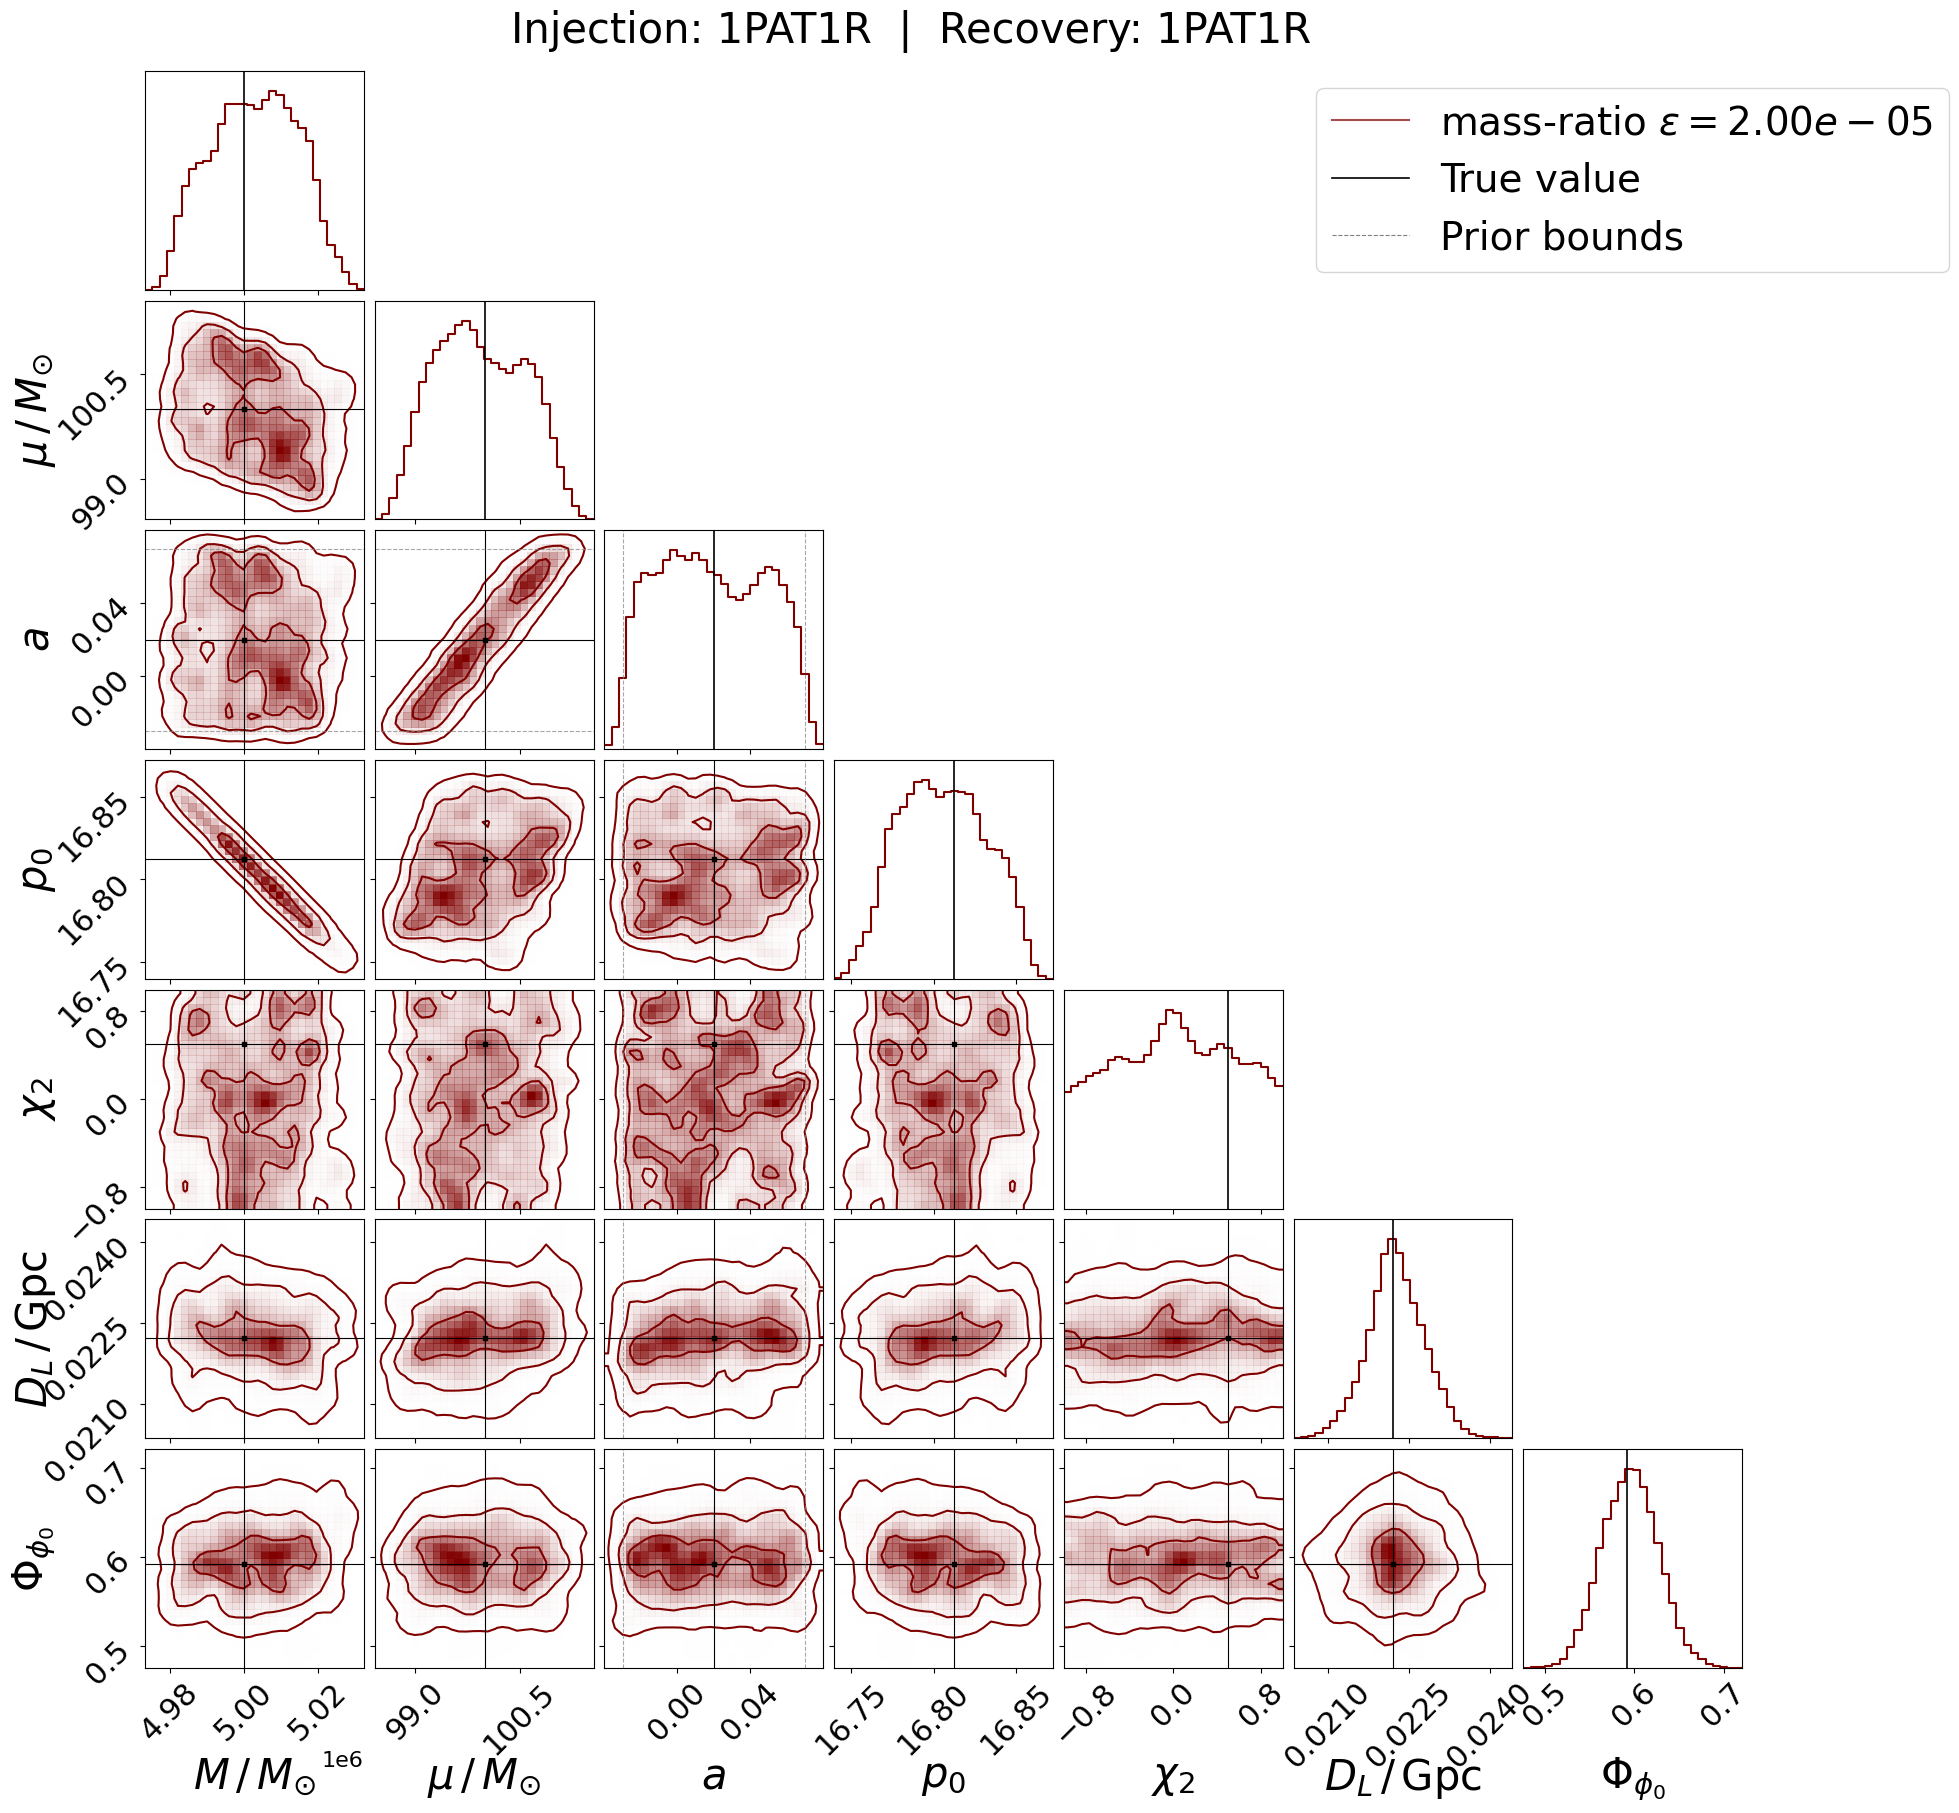

In [58]:
# samples_dict: key = legend label; value = dict with 'color' and 'samples'.
# Add extra entries here to overlay additional posteriors (e.g. higher temps).
samples_dict = {
    rf"mass-ratio $\epsilon = {emri['mu'] / emri['M']:.2e}$": {
        'color':   posterior_color,
        'samples': samples_per_temp[0],
    },
}

plot_name_intrinsic = f'{run_dir}/Review_1PAT1R_test1'

fig = corner_plot(
    samples_dict,
    true_vals,
    param_names,
    inj_model=inj_wf['model'],
    rec_model=rec_wf['model'],
    exclude_sky=True,          # intrinsic + phases only
    plot_name=plot_name_intrinsic,
    range_overrides={
        'M':  1.2,         
        'mu': 1.2,   
        'a': 1.2,
        'p0': 1.2,
        'chi2': 1.0
    },
    prior_bounds=prior_bounds,
    save_dpi=100
)
plt.show()

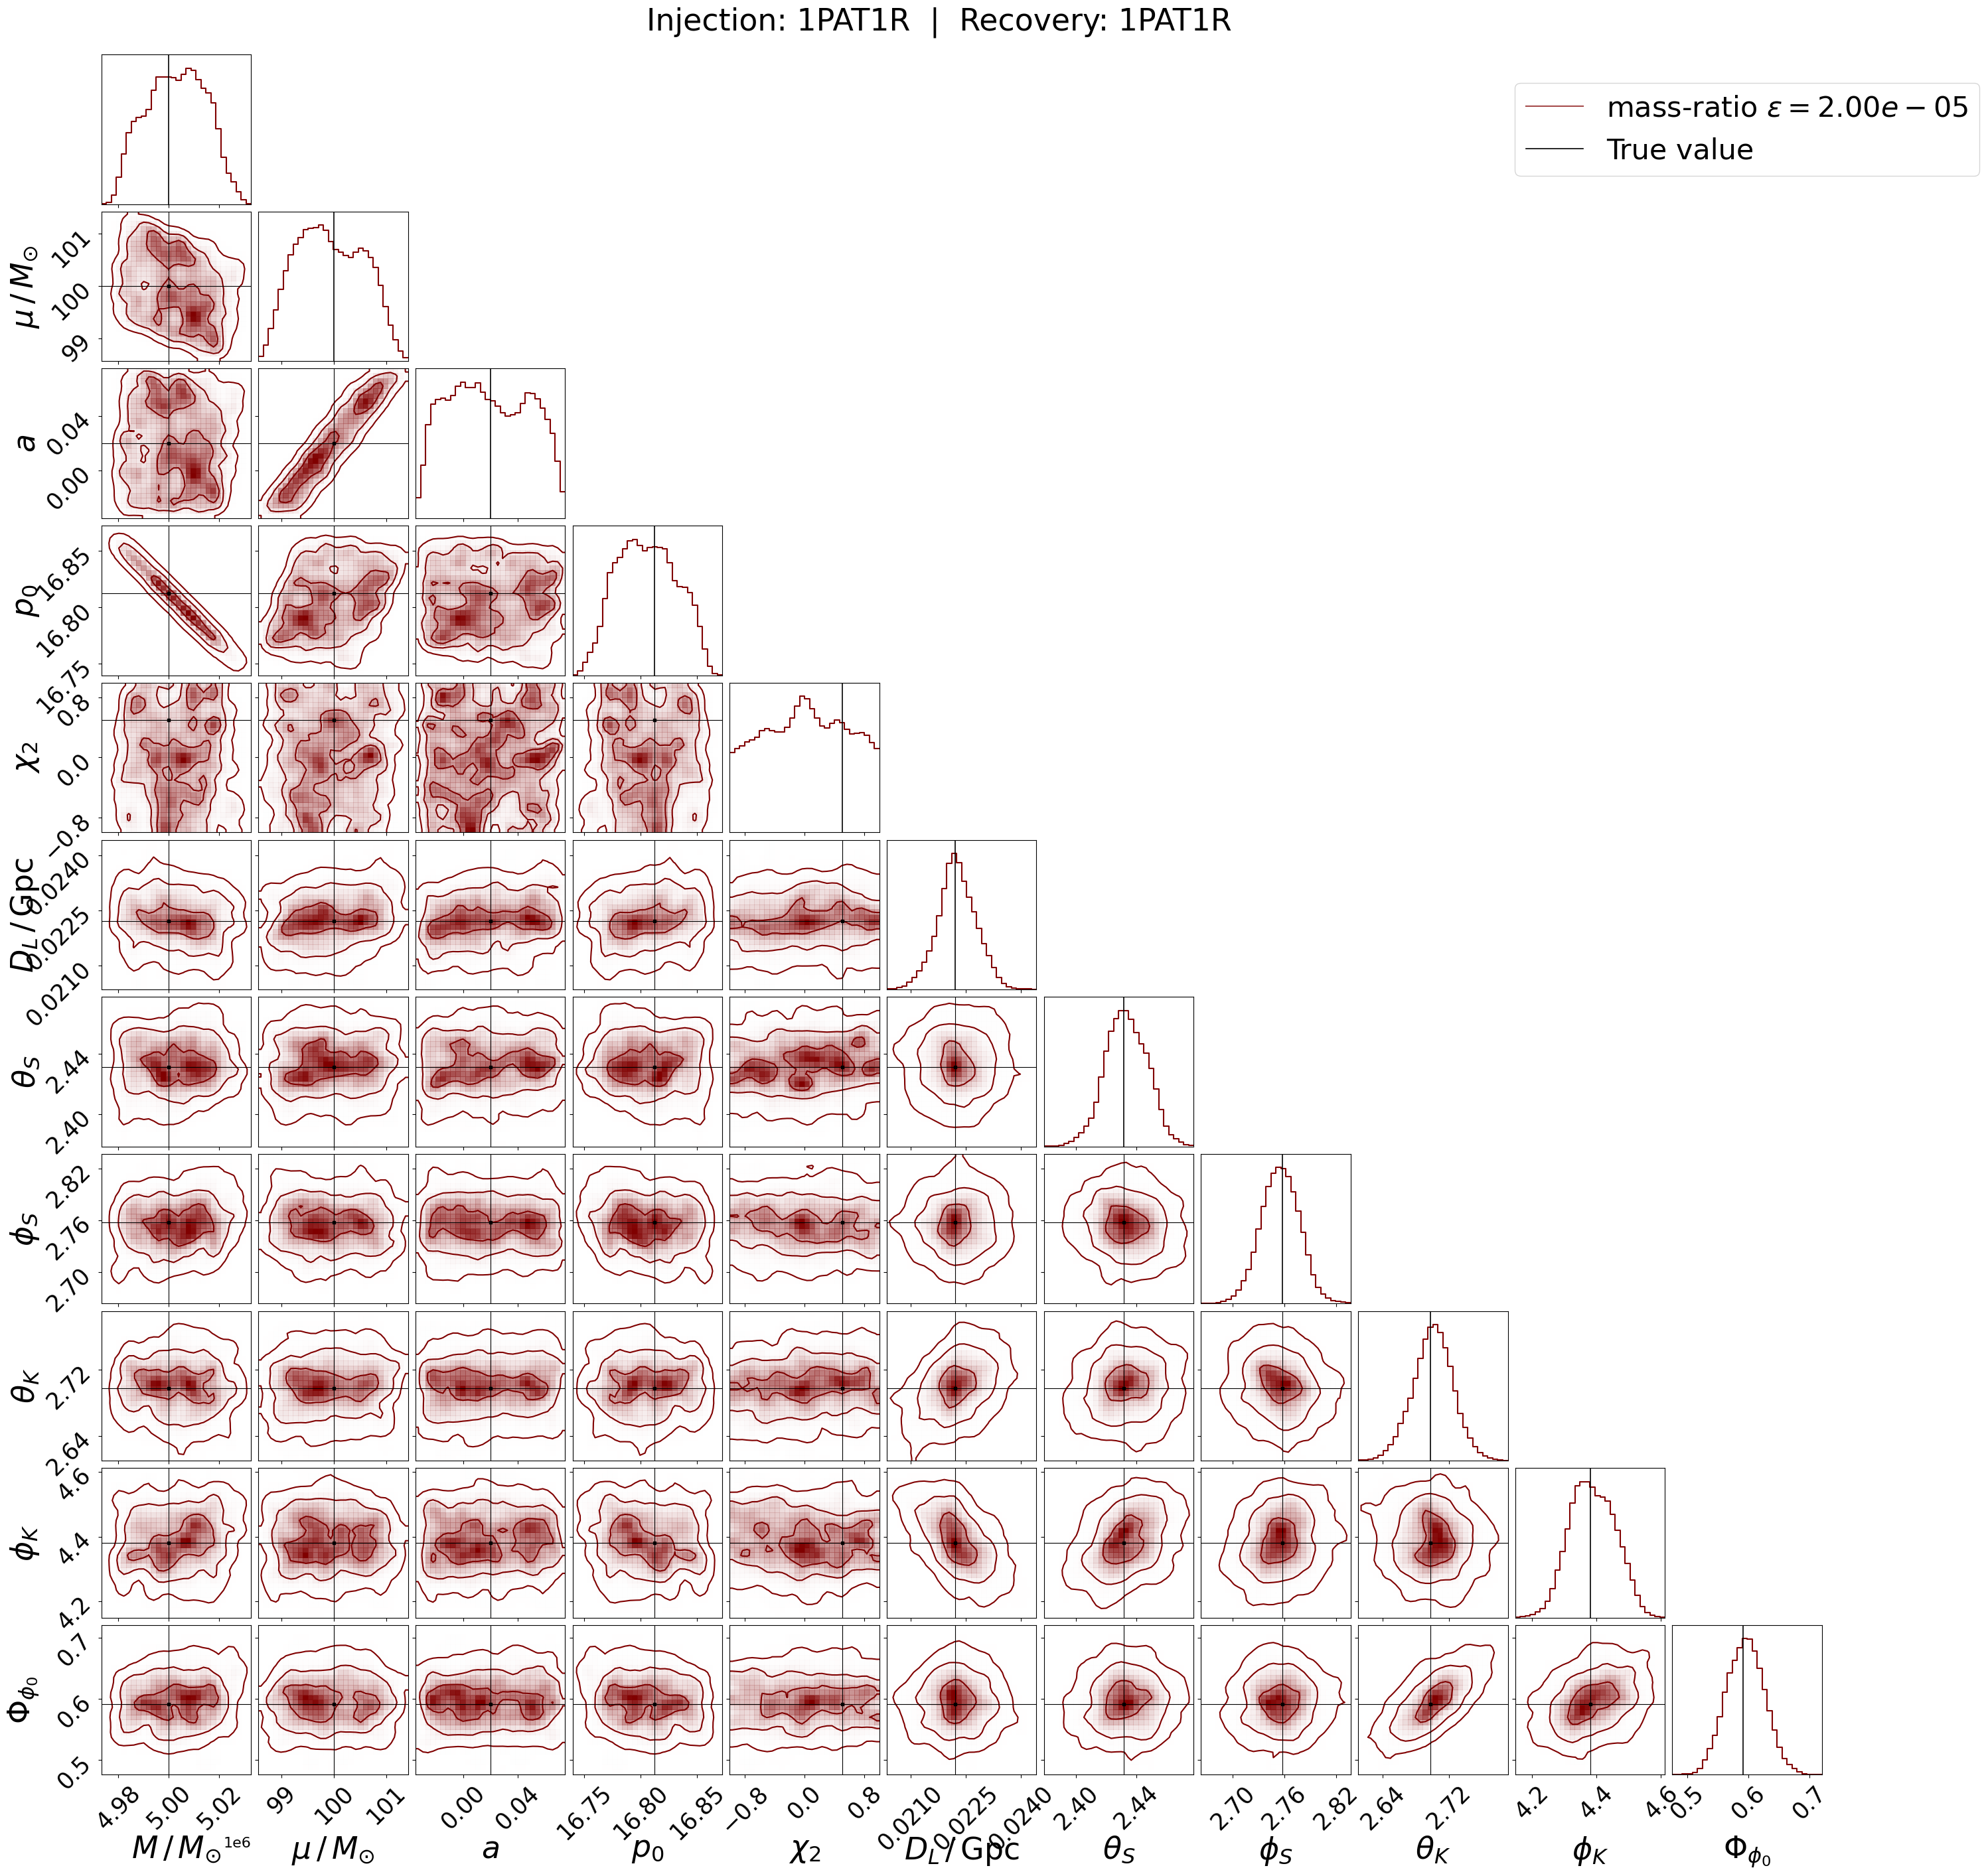

In [59]:
# Full corner plot including sky-angle parameters
plot_name_full = f'{run_dir}/MH_{src_index}_corner_full'
fig = corner_plot(
    samples_dict,
    true_vals,
    param_names,
    inj_model=inj_wf['model'],
    rec_model=rec_wf['model'],
    exclude_sky=False,
    plot_name=plot_name_full,
    range_overrides={
        'M':  1.2,         
        'mu': 1.1,   
        'a': 1.1,
        'p0': 1.2,
        'chi2': 1.0
    },
    save_dpi=60
)
plt.show()

If semi-latus rectum and primary mass are completely degenerate, that indicates the injected signal does not have any chirp at all.  

What happened in the secondary mass? Why is this behaving weird? The signal shows some chirp but is not plunging within 2 years. There is only slight curvature of the tracks, that may not be enough to break the degeneracy of the mass-ratio. Also the primary mass is not very well resolved. 

## Sky position

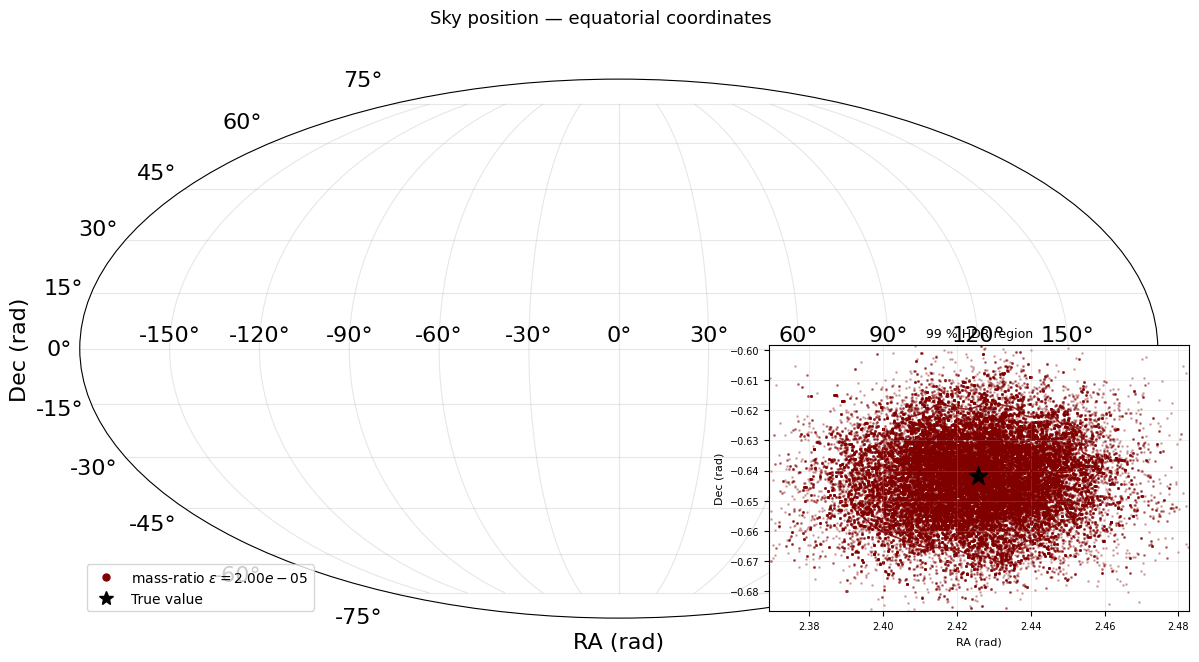

In [18]:
theta_S_true = float(emri['theta_S']) if 'theta_S' in emri else None
phi_S_true   = float(emri['phi_S'])   if 'phi_S'   in emri else None

plot_name_sky = f'{os.getcwd()}/MH_{src_index}_sky_position'

fig = plot_sky_position(
    samples_dict,
    param_names,
    true_theta_S=theta_S_true,
    true_phi_S=phi_S_true,
    plot_name=plot_name_sky,
)

## Convergence tests

The following plots track the running marginal variance (diagonal of the sample covariance) as a function of iteration.
In the ideal case, the plot shapes would have the following characteristics:
1. Rises from zero as walkers spread from their starting points                                                                                     2. Passes through a rapid-growth phase during burn-in (We should have filtered this phase during the earlier inspiral)
3. Flattens into a stable plateau: the dashed line (`var[-1]`) should coincide with where the curve stopped changing                                 4. No systematic drift, no sudden jumps in the last iterations for all parameters.                                                                                                
Convergence criteria.                                                                                                                               - The curve has plateaued (zero or near-zero slope in the tail) for all parameters                                                                   
- The dashed asymptote is reached well before the end of the run. If the curve is still rising at the end, more iterations are needed               
- Sudden jumps indicate a walker discovered a new mode late so the variance will then settle to a new plateau, which is fine as long as R-hat also converges.
- A flat curve at a very small value from the start means walkers are stuck (dead sampler issue, no convergence)   

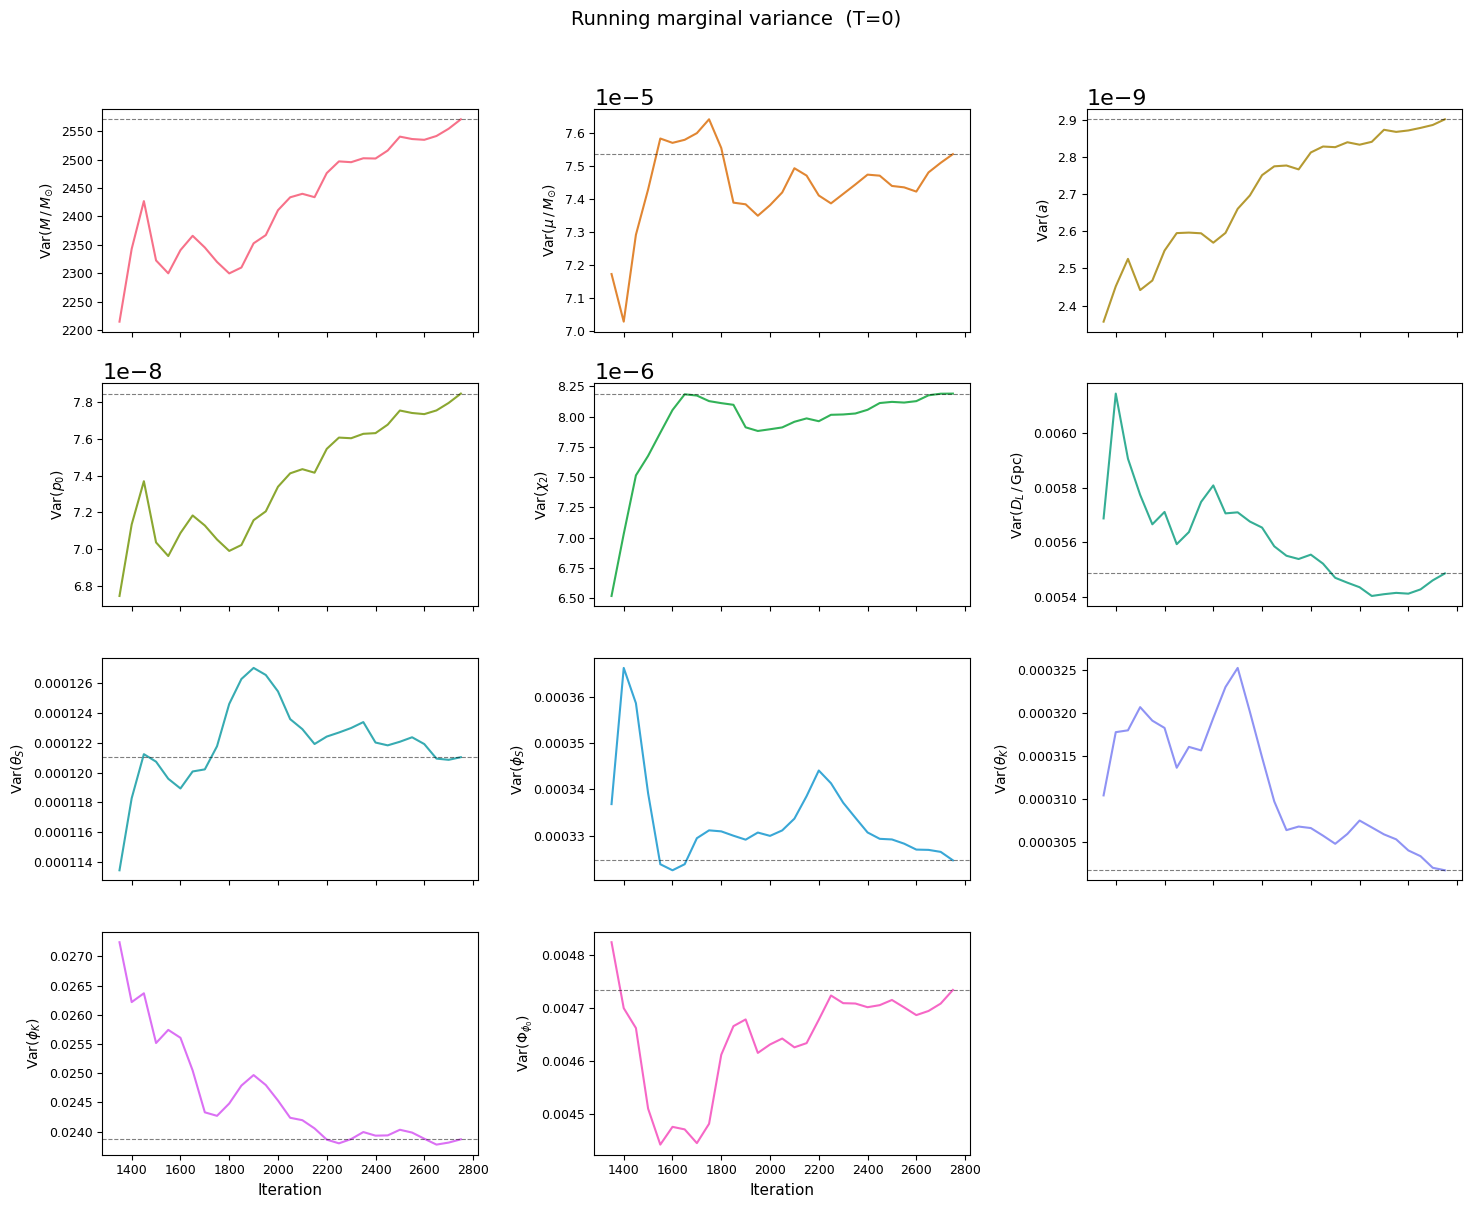

In [42]:
plot_name_cov = f'{run_dir}/test_{test_case}_covariance'

fig = plot_covariance_evolution(
    reader, param_names,
    discard=discard, temp=0, step=50,
    plot_name=plot_name_cov,
)

We can look at the Gelman-Rubin criterion for convergence. R-hat compares between-chain variance to within-chain variance across walkers. Formally, for M walkers of length N:                                          

- $W   = \text{mean of within-walker variances}$                                                                                                     
- $B   = \frac{N}{M-1}  \Sigma (\mu_m - \mu)^2$ -> varaince between difference walkers    
- $\hat{V}   = \frac{N-1}/{N}  W + B/N   $                                                                              - $\hat{R}   = sqrt(\hat{V} / W)$                                                                                     


If all walkers have converged to the same posterior, B/W goes to 1, so R-hat goes to 1. Early on, walkers sample different regions and B >> W, giving R-hat >> 1.                               
                  
In the ideal case, the function `plot_gelman_rubin` computes this running at some intermediate checkpoints:                                                                                    
1. Starts high (commonly 1.1–2+) as walkers haven't mixed                                                                                           
2. Drops monotonically and rapidly during the mixing phase (from parallel tempering)
3. Plateaus and stabilises below the threshold dashed line (default convergence_threshold=1.01, this is a common value for rather strict analysis)   
4. The grey dotted line at 1.0 is the theoretical floor and so the curve should asymptotes towards this value. If it dips below, something went wrong and we need to check.                                                                    
                                                                                                                                            
#### Convergence criterion                                 
We combine the variance evolution of the diagonal elemnts as a function of iteration with the Gelman-Rubin criterion to assess whether the run has concluded or not. All parameters must simultaneously satisfy R-hat < threshold and the curve must be flat a transient dip followed by a rise means the chain is still exploring. The standard rule of thumb is R-hat < 1.01 (strict) or < 1.1 (lenient). Check that the plateau is stable over the last ~30% of iterations.  

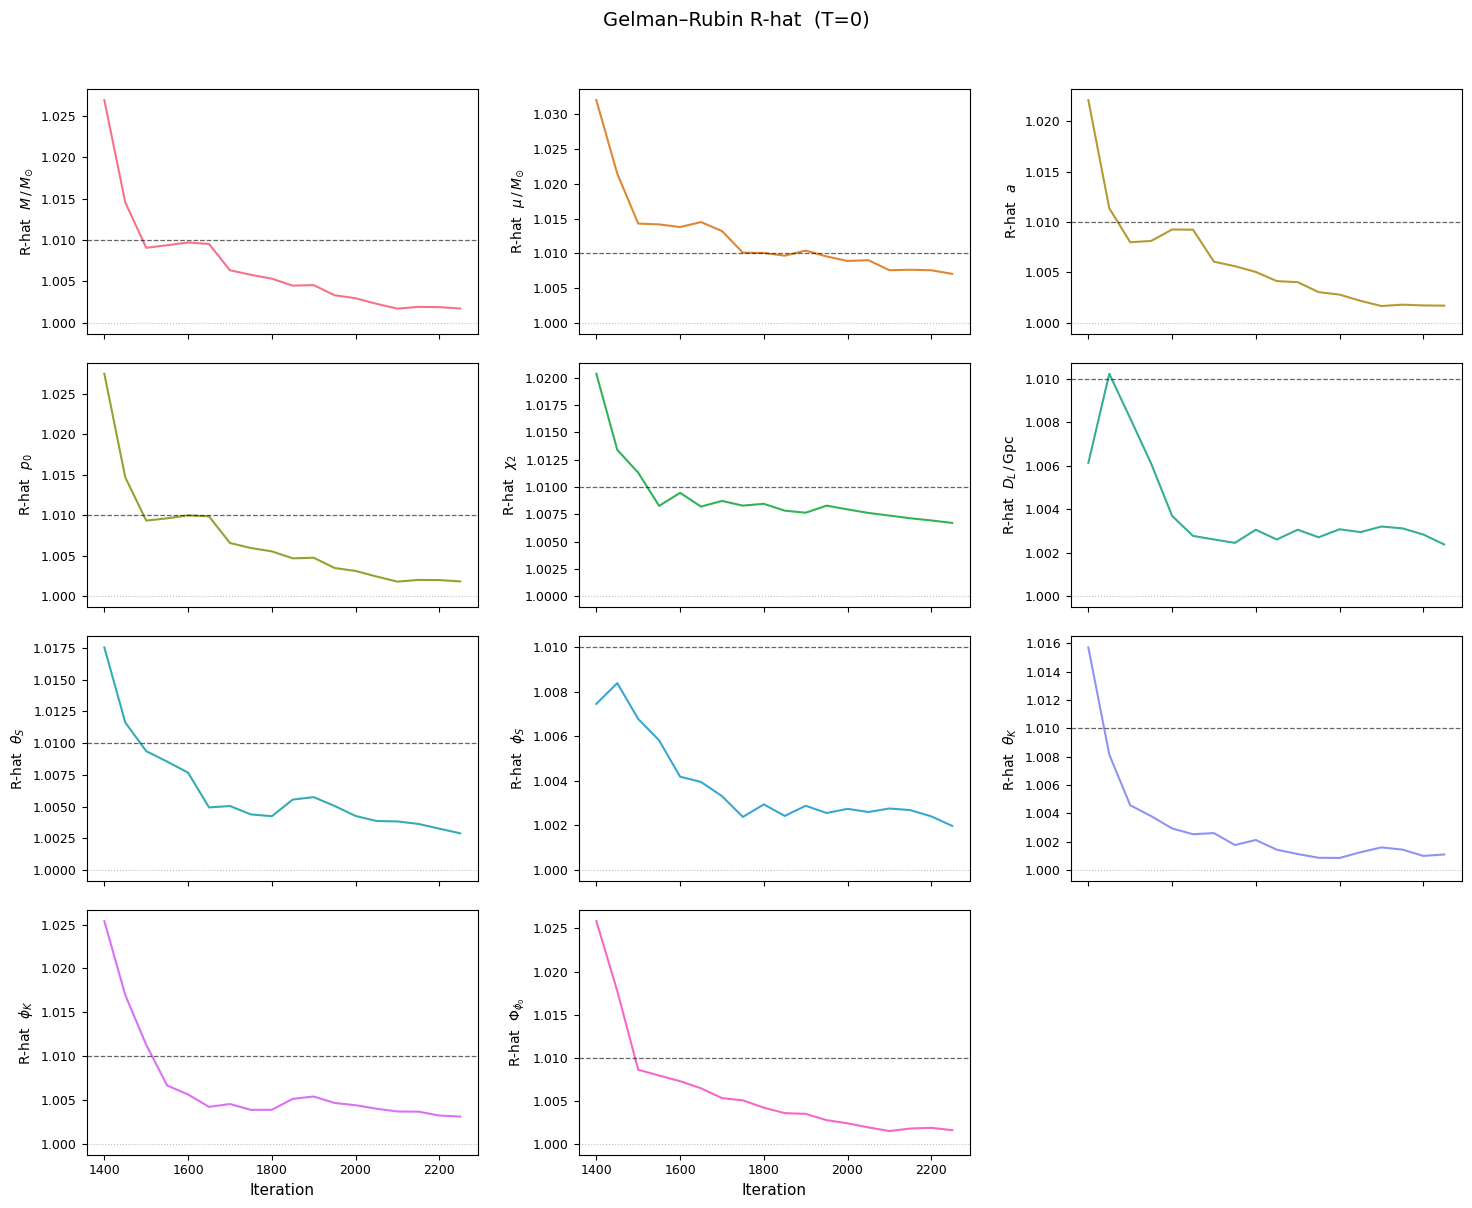

Final R-hat values:
  M                1.0017
  mu               1.0070
  a                1.0017
  p0               1.0018
  chi2             1.0067
  d_L              1.0024
  theta_S          1.0029
  phi_S            1.0020
  theta_K          1.0011
  phi_K            1.0031
  Phi_phi0         1.0016


In [17]:
plot_name_rhat = f'{run_dir}/test_{test_case}_gelman_rubin'

rhat = plot_gelman_rubin(
    reader, param_names,
    discard=discard, temp=0, step=50,
    convergence_threshold=1.01,
    plot_name=plot_name_rhat,
)
print('Final R-hat values:')
for name, rh in zip(param_names, rhat[-1]):
    print(f'  {name:<16} {rh:.4f}')

## Some extra plots
Use the statistical tools in seaborn to inspect properties of the inferred posterior distributions, such as skewness, multimodality, etc. This can help identify potential issues with the sampling process or the model fit.

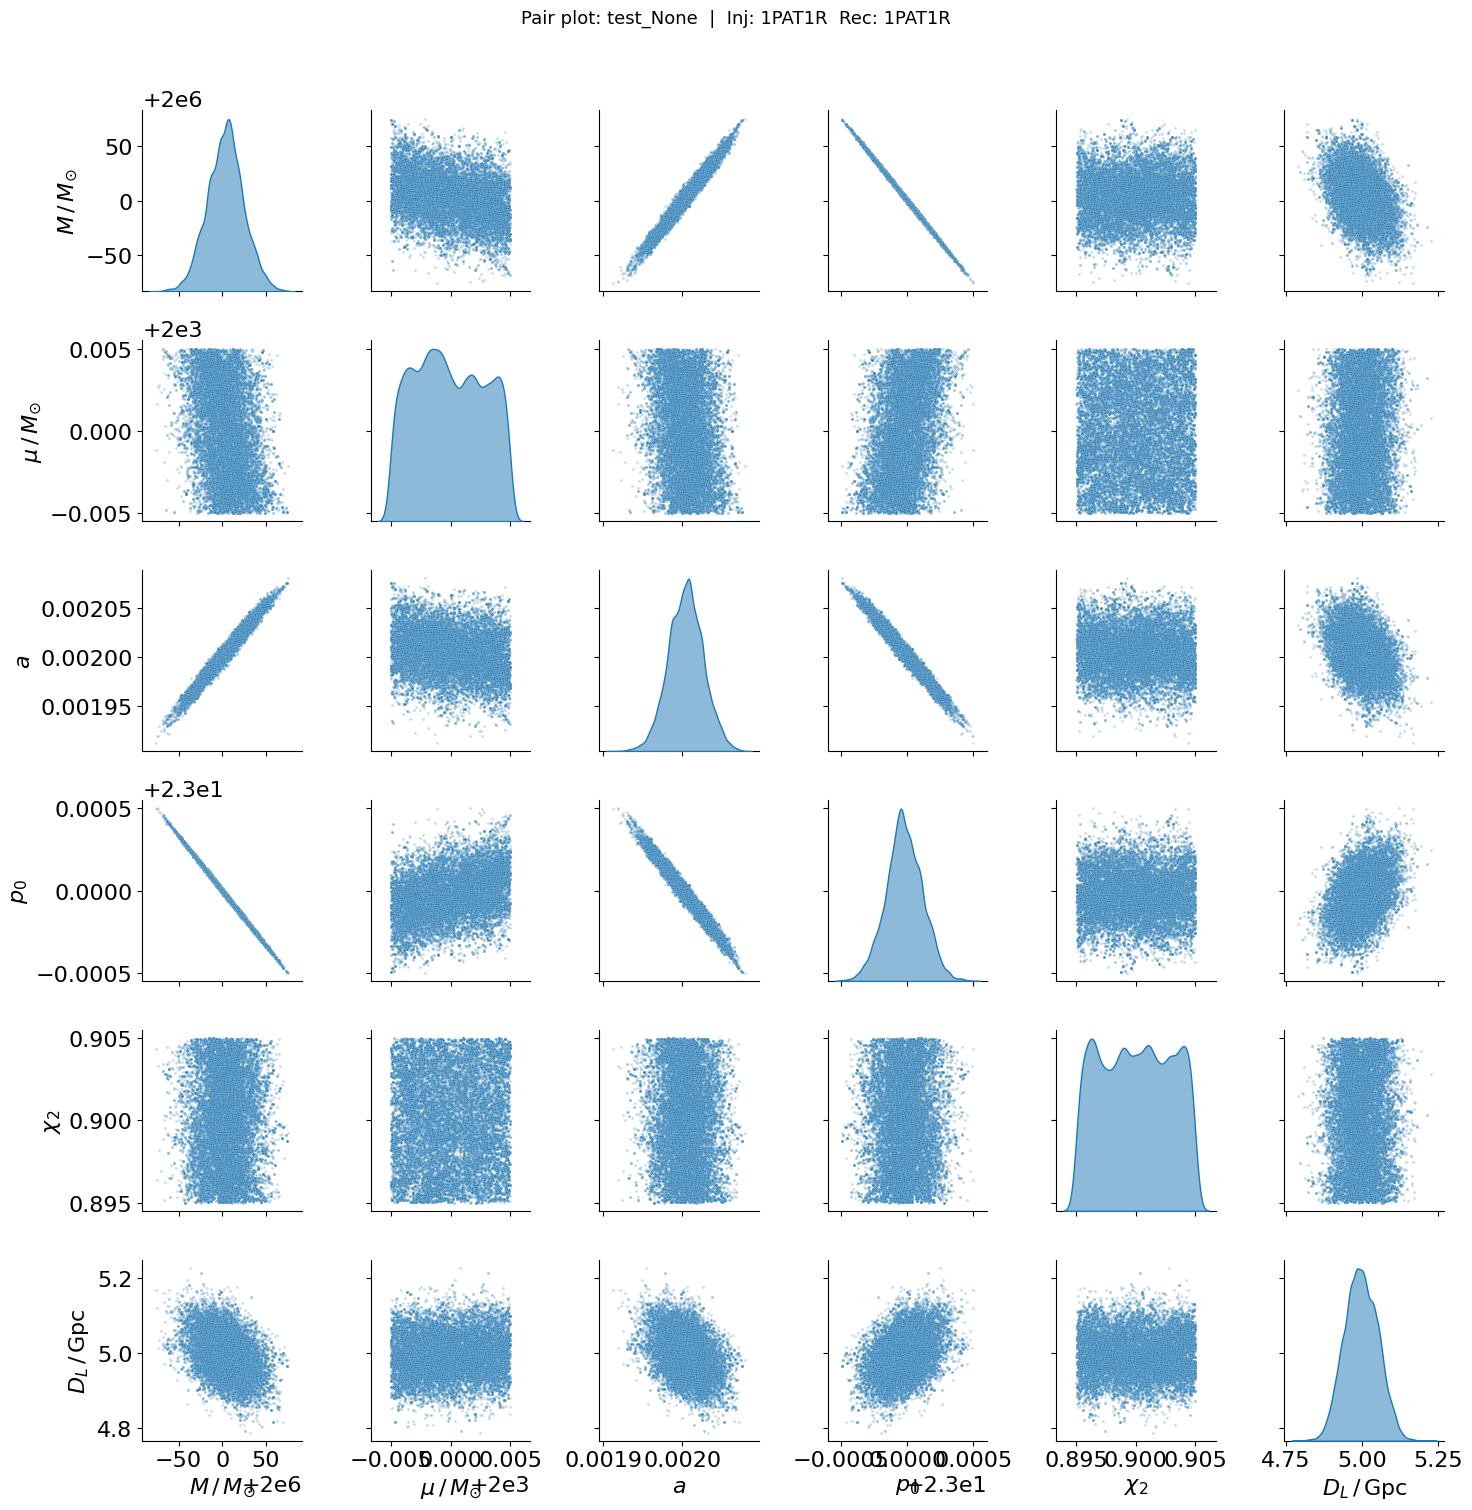

/vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/src/analysis.py:982: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


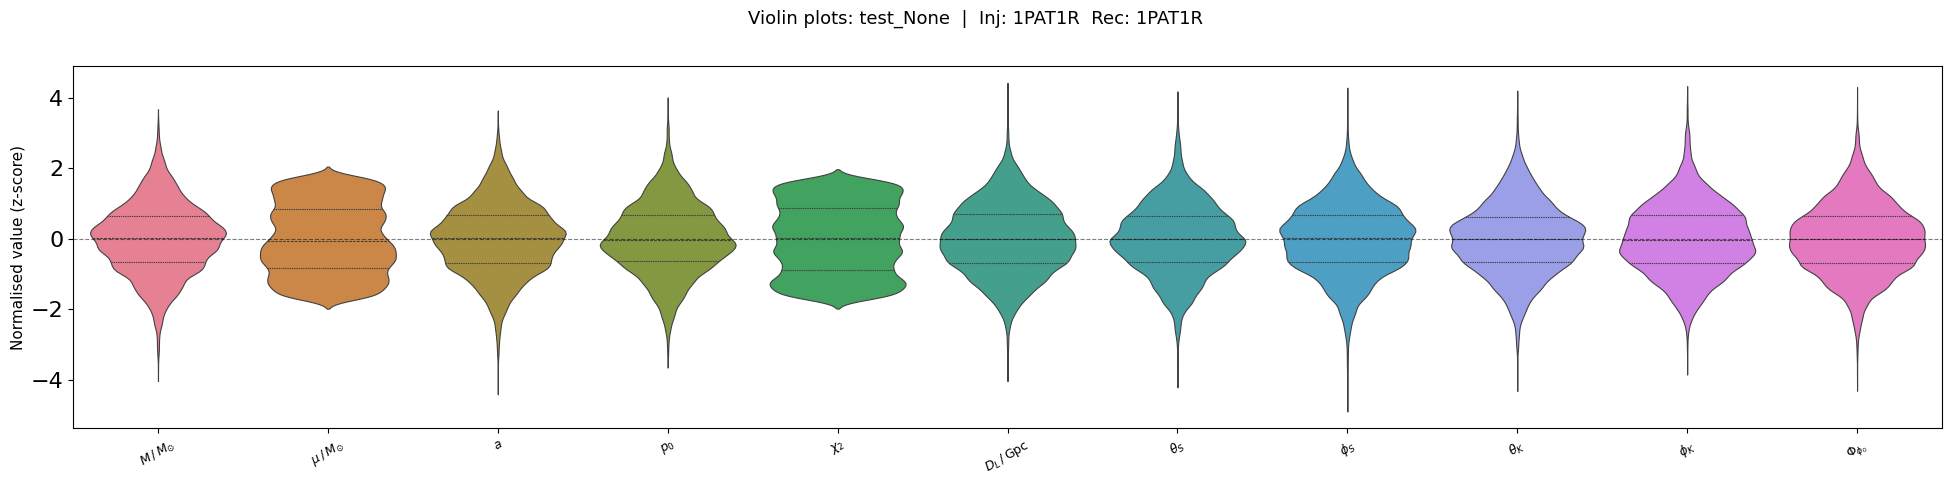

In [18]:
plot_name_sb = f'{run_dir}/test_{test_case}_seaborn'

title = (
    f'test_{test_case}  |  '
    f"Inj: {inj_wf['model']}  Rec: {rec_wf['model']}"
)

fig = plot_seaborn_diagnostics(
    samples_per_temp[0],
    param_names,
    title=title,
    max_pair_params=6,
    plot_name=plot_name_sb,
)

## Quantitative summary

In [19]:
cold_samples = samples_per_temp[0]   # (N_samples, N_params)

rows = []
for k, name in enumerate(param_names):
    col   = cold_samples[:, k]
    med   = np.median(col)
    lo68, hi68 = np.percentile(col, [16.0, 84.0])
    lo90, hi90 = np.percentile(col, [ 5.0, 95.0])
    half_68    = (hi68 - lo68) / 2.0
    bias_sigma = (med - true_vals[k]) / half_68 if half_68 > 0 else float('nan')
    in_90ci    = lo90 <= true_vals[k] <= hi90
    rows.append(dict(
        name       = name,
        true       = true_vals[k],
        median     = med,
        lo68       = lo68,
        hi68       = hi68,
        ci90_width = hi90 - lo90,
        bias_sigma = bias_sigma,
        in_90ci    = in_90ci,
    ))

header = (f"{'Param':<16}  {'True':>12}  {'Median':>12}  "
          f"{'[16th':>12}  {'84th]':>12}  {'90% CI':>10}  {'bias/σ':>7}  {'in 90%CI':>9}")
sep = "-" * len(header)
print(header)
print(sep)
for r in rows:
    flag = "yes" if r['in_90ci'] else "NO"
    print(f"{r['name']:<16}  {r['true']:>12.5g}  {r['median']:>12.5g}  "
          f"{r['lo68']:>12.5g}  {r['hi68']:>12.5g}  {r['ci90_width']:>10.4g}  "
          f"{r['bias_sigma']:>7.2f}  {flag:>9}")
print(sep)
print(f"\n{'N cold samples:':<20} {len(cold_samples)}")


Param                     True        Median         [16th         84th]      90% CI   bias/σ   in 90%CI
--------------------------------------------------------------------------------------------------------
M                      2.5e+06         2e+06         2e+06         2e+06       69.54  -24912.41         NO
mu                        2500          2000          2000          2000    0.008899  -149894.82         NO
a                        0.002     0.0020048      0.001983     0.0020259   7.372e-05     0.22        yes
p0                          23            23            23            23   0.0004619    -0.22        yes
chi2                       0.9       0.90003       0.89652       0.90347    0.008997     0.01        yes
d_L                          5        4.9965        4.9411        5.0539      0.1791    -0.06        yes
theta_S                0.56891        0.5687       0.55559       0.58246     0.04471    -0.02        yes
phi_S                   3.0696        3.0727      

## Plots for review tests

In [19]:
sampling_dir

'/vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/scripts/sampling_data'

### Test 1: spin out of accurate regime

In [20]:
index = 1

In [22]:
# hardcoded path
full_1PA = f'{sampling_dir}/Review_test_2_inj_1PA_rec_1PA_2026-06-24_14-15-03'

# Load configs for each run to derive the correct parameter lists
config_full_1PA = param_load(glob.glob(os.path.join(full_1PA, '*.yaml'))[0])


# Derive sampled parameters
param_names_full, injected_vals = sampled_params_from_config(config_full_1PA)
print(f'Full 1PA params ({len(param_names_full)}): {param_names_full}')

# Locate HDF5 backends using the hard-coded paths
h5_full = glob.glob(os.path.join(full_1PA, 'SamplingResults_*.h5'))

# Validation and Loading
for label, h5_list in zip(['Full'], [h5_full]):
    if not h5_list:
        raise FileNotFoundError(f'No HDF5 found for {label} run.')
    print(f'\nLoading {label}: {h5_list[0]}')

Full 1PA params (11): ['M', 'mu', 'a', 'p0', 'chi2', 'd_L', 'theta_S', 'phi_S', 'theta_K', 'phi_K', 'Phi_phi0']

Loading Full: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/scripts/sampling_data/Review_test_1_inj_1PA_rec_1PA_2026-06-12_09-46-51/SamplingResults_Review_test_1_inj_1PA_rec_1PA_fixedx_I0_1.0_e0_0.0_Phi_theta0_6.13001602516006_Phi_r0_4.782381792256834_2026-06-12_09-46-51.h5


In [27]:
# Set discard (burn-in) values for each run
discard_full = 3000

# Load 'Full 1PA' samples
named_full, reader_full, log_like_full, (N_iters_full, N_temps_full, N_walkers_full, _) = \
    load_samples_named(h5_full[0], param_names_full, discard=discard_full)

# Print summary for all three
print(f'Full 1PA: {N_iters_full} iters × {N_temps_full} temps × {N_walkers_full} walkers')

Full 1PA: 2179 iters × 2 temps × 40 walkers


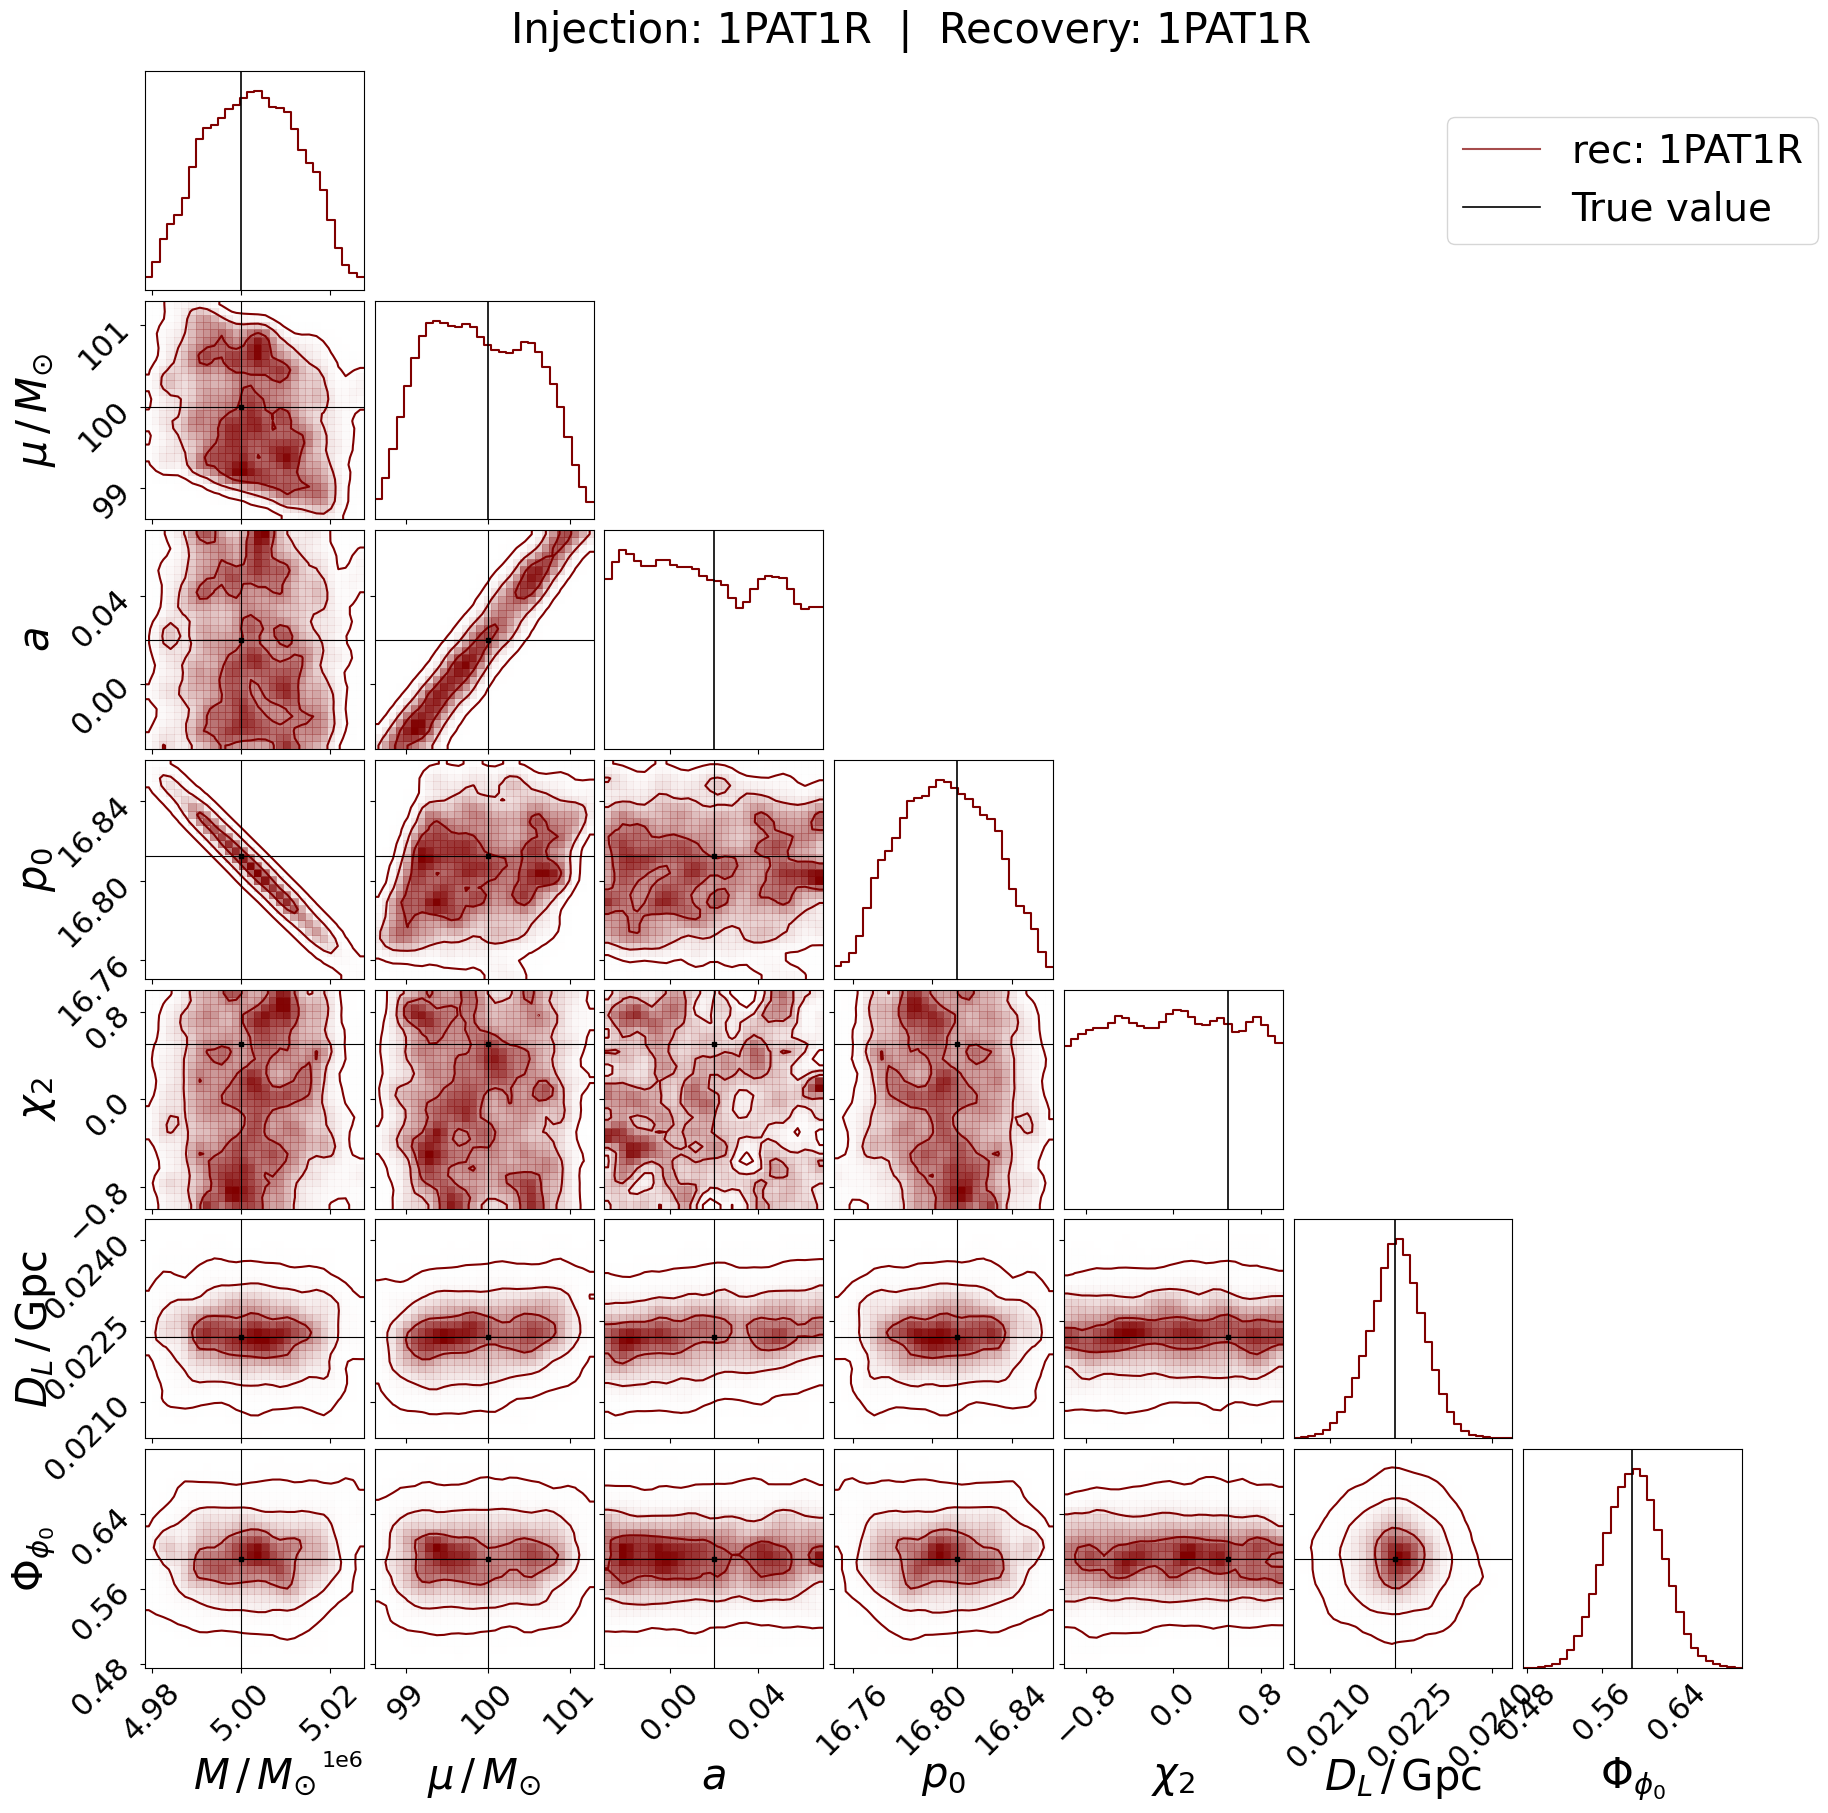

In [29]:
samples_dict_1PA = {
    r'rec: 1PAT1R': {
        'color':   'maroon',
        'samples': named_full,
    },
}

plot_name_intrinsic = f'{os.getcwd()}/Plots/review/Review_{index}_corner_intrinsic'

fig = corner_plot(
    samples_dict_1PA,
    injected_vals,
    param_names_full, 
    inj_model='1PAT1R',
    rec_model=r'1PAT1R',
    exclude_sky=True,
    plot_name=plot_name_intrinsic,
)
plt.show()

### Review test 2: edge of p0 grid


In [4]:
index = 2

In [5]:
# hardcoded path
full_1PA = f'{sampling_dir}/Review_test_2_inj_1PA_rec_1PA_2026-06-13_06-48-21'

# Load configs for each run to derive the correct parameter lists
config_full_1PA = param_load(glob.glob(os.path.join(full_1PA, '*.yaml'))[0])


# Derive sampled parameters
param_names_full, injected_vals = sampled_params_from_config(config_full_1PA)
print(f'Full 1PA params ({len(param_names_full)}): {param_names_full}')

# Locate HDF5 backends using the hard-coded paths
h5_full = glob.glob(os.path.join(full_1PA, 'SamplingResults_*.h5'))

# Validation and Loading
for label, h5_list in zip(['Full'], [h5_full]):
    if not h5_list:
        raise FileNotFoundError(f'No HDF5 found for {label} run.')
    print(f'\nLoading {label}: {h5_list[0]}')

Full 1PA params (11): ['M', 'mu', 'a', 'p0', 'chi2', 'd_L', 'theta_S', 'phi_S', 'theta_K', 'phi_K', 'Phi_phi0']

Loading Full: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/scripts/sampling_data/Review_test_2_inj_1PA_rec_1PA_2026-06-13_06-48-21/SamplingResults_Review_test_2_inj_1PA_rec_1PA_fixedx_I0_1.0_e0_0.0_Phi_theta0_6.13001602516006_Phi_r0_4.782381792256834_2026-06-13_06-48-21.h5


In [6]:
# Set discard (burn-in) values for each run
discard_full = 4000

# Load 'Full 1PA' samples
named_full, reader_full, log_like_full, (N_iters_full, N_temps_full, N_walkers_full, _) = \
    load_samples_named(h5_full[0], param_names_full, discard=discard_full)

# Print summary for all three
print(f'Full 1PA: {N_iters_full} iters × {N_temps_full} temps × {N_walkers_full} walkers')

Full 1PA: 1970 iters × 2 temps × 40 walkers


In [8]:
injected_vals

array([5.00000000e+06, 1.00000000e+02, 2.00000000e-02, 2.99882870e+01,
       5.00000000e-01, 4.42597414e-04, 2.43145464e+00, 2.75755456e+00,
       2.69736492e+00, 4.38169255e+00, 5.91733729e-01])

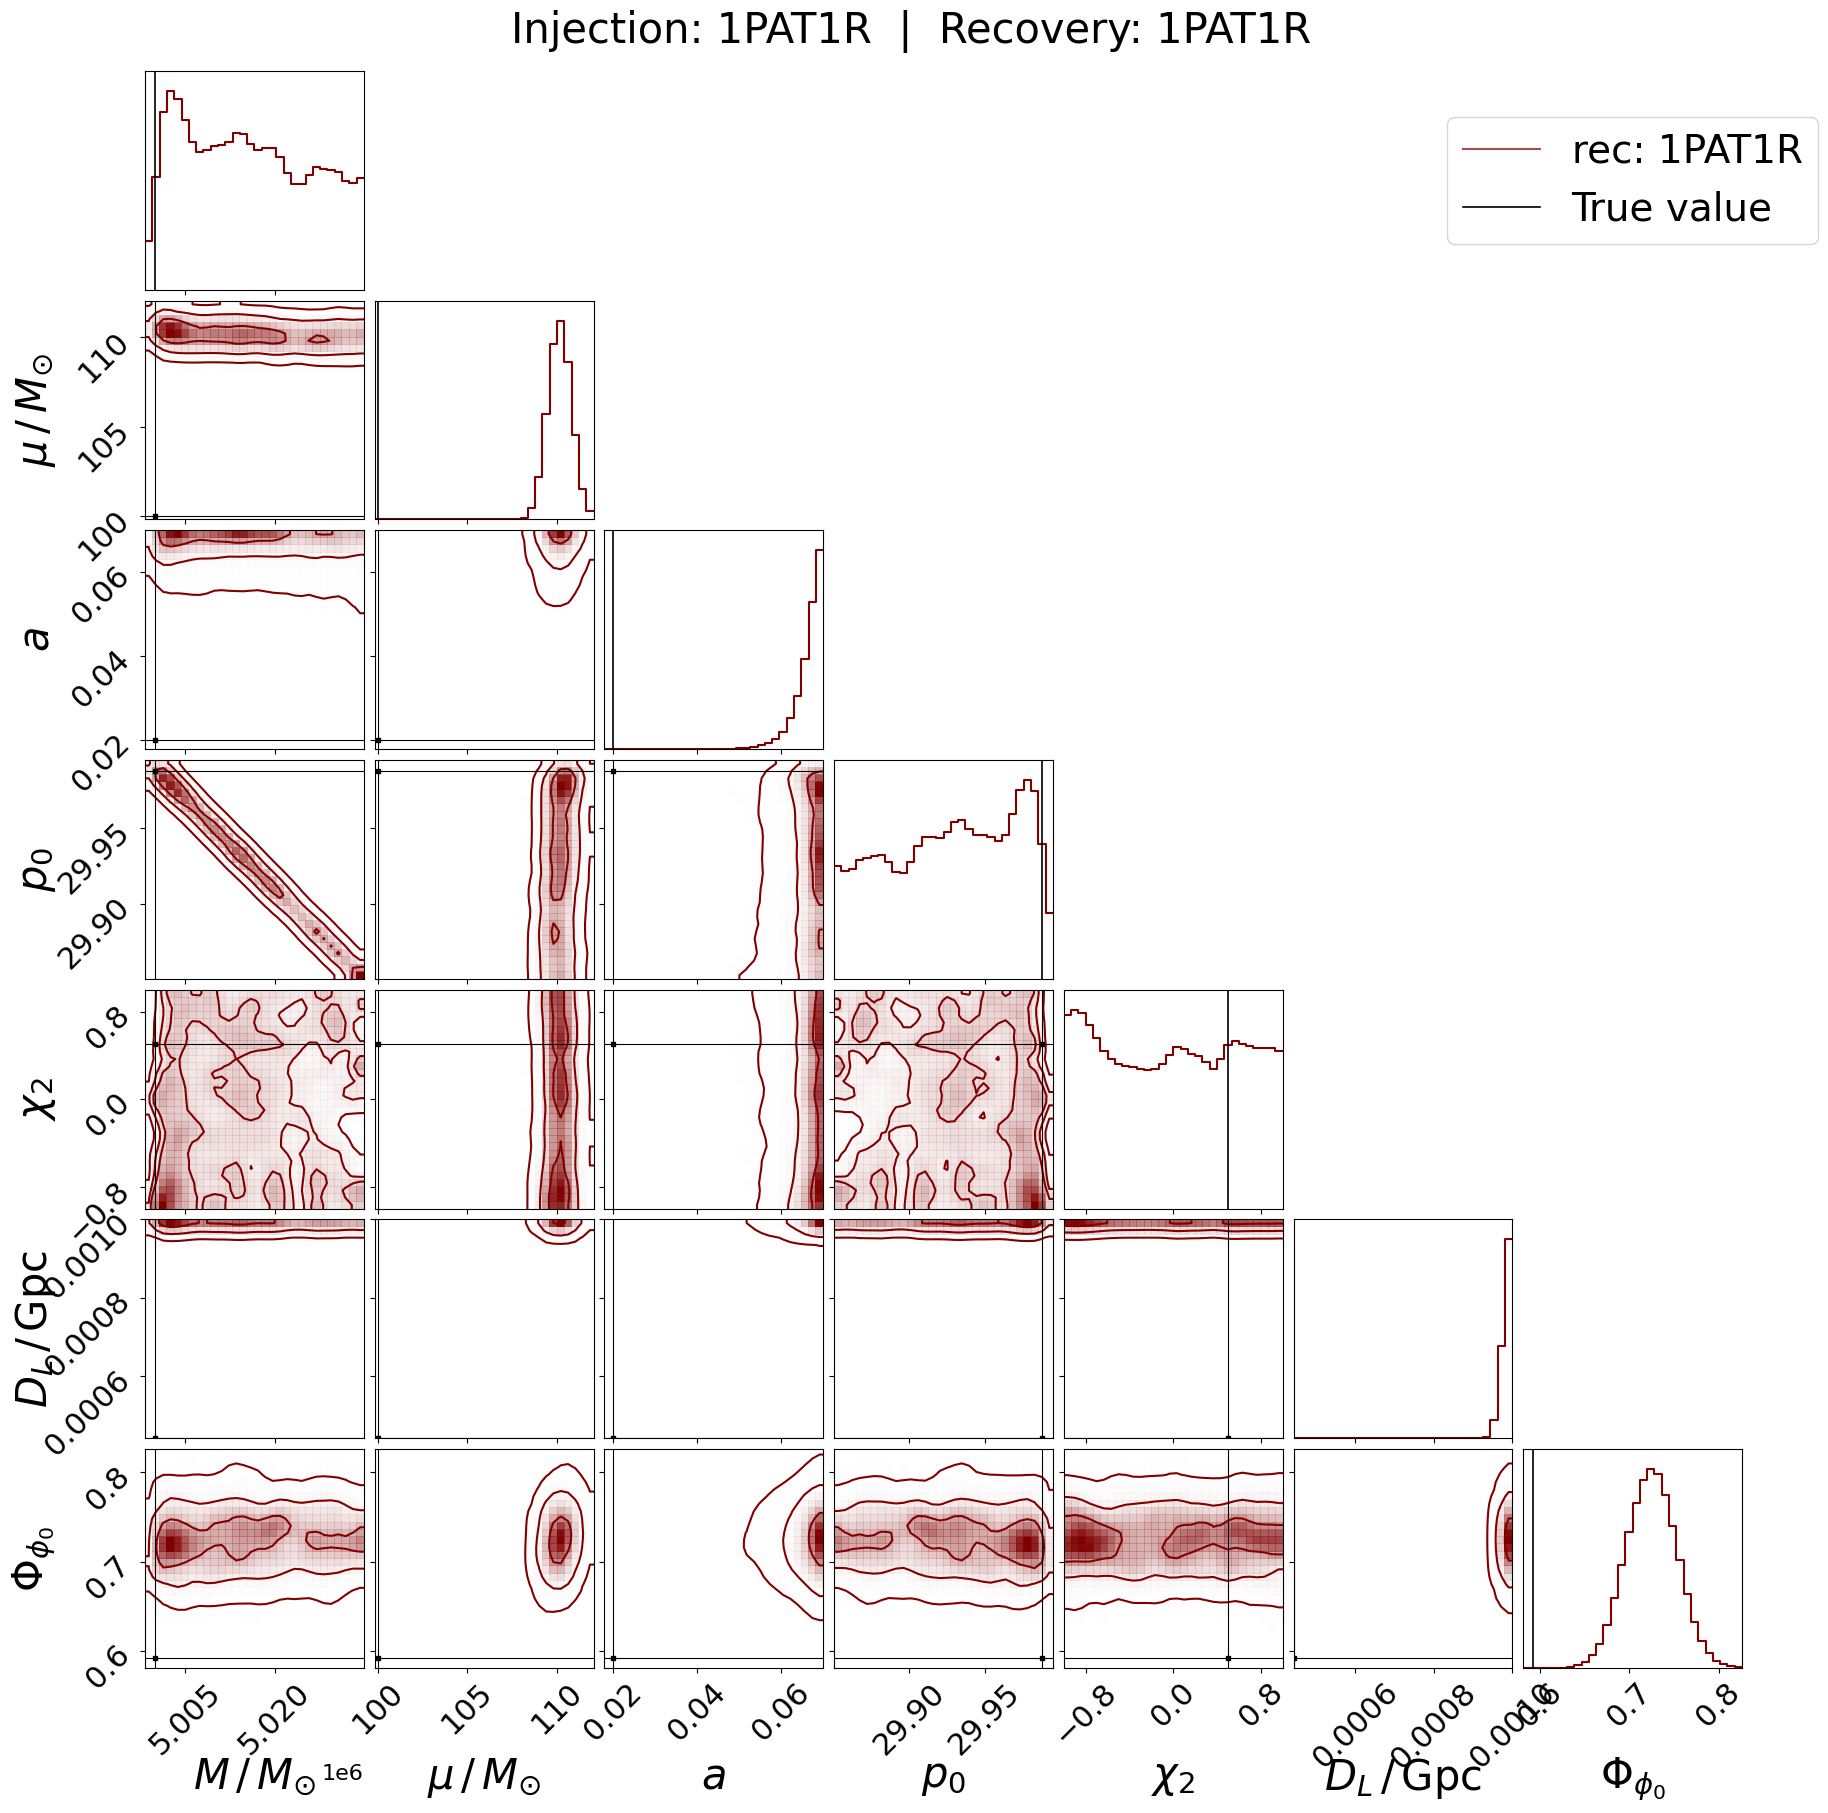

In [7]:
samples_dict_1PA = {
    r'rec: 1PAT1R': {
        'color':   'maroon',
        'samples': named_full,
    },
}

plot_name_intrinsic = f'{os.getcwd()}/Plots/review/Review_{index}_corner_intrinsic'

fig = corner_plot(
    samples_dict_1PA,
    injected_vals,
    param_names_full, 
    inj_model='1PAT1R',
    rec_model=r'1PAT1R',
    exclude_sky=True,
    plot_name=plot_name_intrinsic,
)
plt.show()

### review test 3: chi2 = 15
secondary spin way out of physical regime

In [9]:
# hardcoded path
full_1PA = f'{sampling_dir}/Review_test_3_inj_1PA_rec_1PA_2026-06-13_06-48-21'

# Load configs for each run to derive the correct parameter lists
config_full_1PA = param_load(glob.glob(os.path.join(full_1PA, '*.yaml'))[0])

# Derive sampled parameters
param_names_full, injected_vals = sampled_params_from_config(config_full_1PA)
print(f'Full 1PA params ({len(param_names_full)}): {param_names_full}')

# Locate HDF5 backends using the hard-coded paths
h5_full = glob.glob(os.path.join(full_1PA, 'SamplingResults_*.h5'))

# Validation and Loading
for label, h5_list in zip(['Full'], [h5_full]):
    if not h5_list:
        raise FileNotFoundError(f'No HDF5 found for {label} run.')
    print(f'\nLoading {label}: {h5_list[0]}')

Full 1PA params (11): ['M', 'mu', 'a', 'p0', 'chi2', 'd_L', 'theta_S', 'phi_S', 'theta_K', 'phi_K', 'Phi_phi0']

Loading Full: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/scripts/sampling_data/Review_test_3_inj_1PA_rec_1PA_2026-06-13_06-48-21/SamplingResults_Review_test_3_inj_1PA_rec_1PA_fixedx_I0_1.0_e0_0.0_Phi_theta0_6.13001602516006_Phi_r0_4.782381792256834_2026-06-13_06-48-21.h5


In [11]:
# Set discard (burn-in) values for each run
discard_full = 3500

# Load 'Full 1PA' samples
named_full, reader_full, log_like_full, (N_iters_full, N_temps_full, N_walkers_full, _) = \
    load_samples_named(h5_full[0], param_names_full, discard=discard_full)

# Print summary for all three
print(f'Full 1PA: {N_iters_full} iters × {N_temps_full} temps × {N_walkers_full} walkers')

Full 1PA: 1784 iters × 2 temps × 40 walkers


/data/leuven/367/vsc36785/miniconda3/envs/emri_env_ddpc/lib/python3.12/site-packages/corner/core.py:928: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  return ax.set_ylim(new_ylim)
/vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/src/analysis.py:500: UserWarning: corner.corner failed for 'rec: 1PAT1R': It looks like the provided 'range' is not valid or the sample is empty.
  warnings.warn(f"corner.corner failed for '{label}': {exc}")


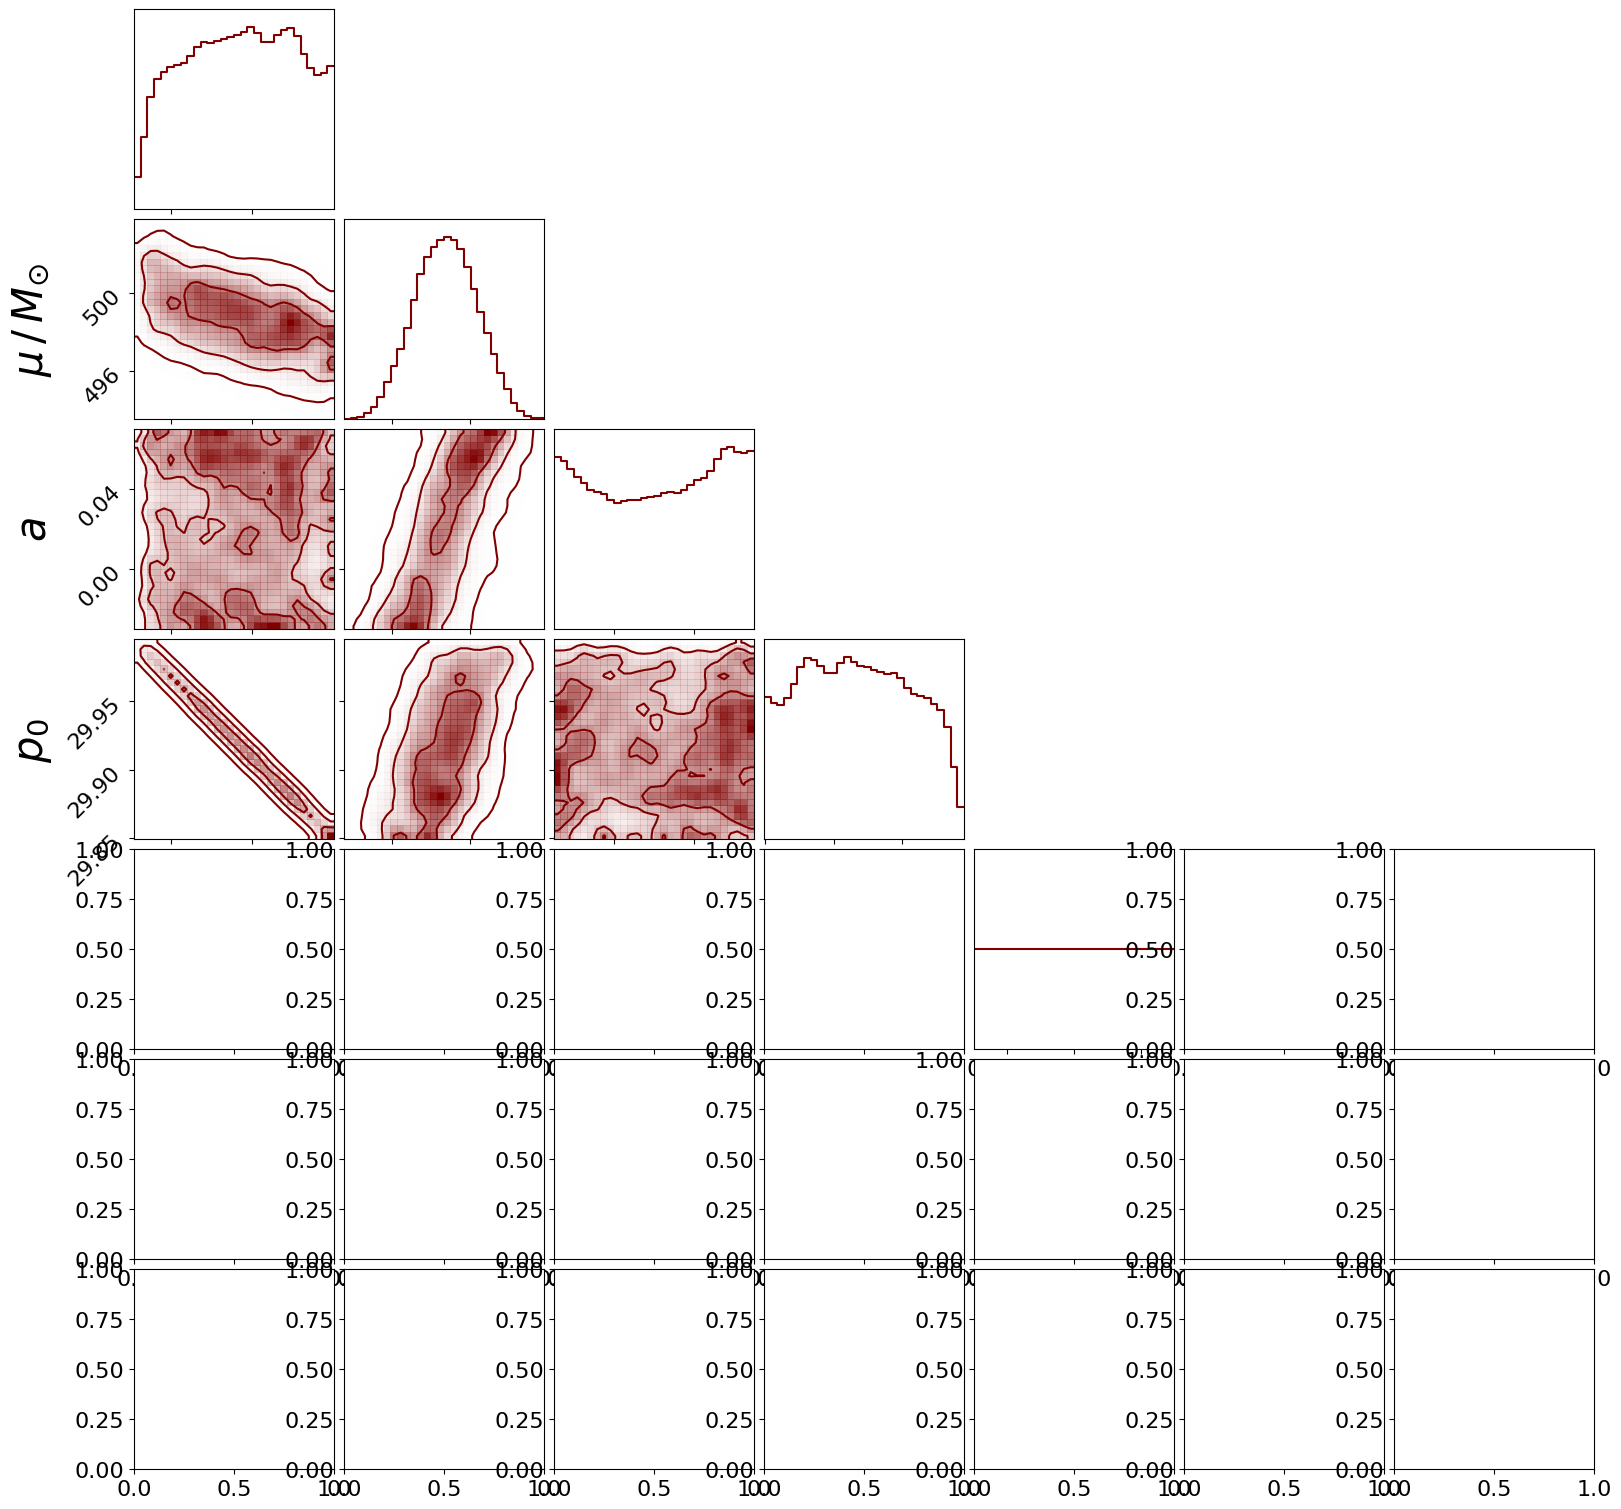

In [12]:
samples_dict_1PA = {
    r'rec: 1PAT1R': {
        'color':   'maroon',
        'samples': named_full,
    },
}

plot_name_intrinsic = f'{os.getcwd()}/Plots/review/Review_{index}_corner_intrinsic'

fig = corner_plot(
    samples_dict_1PA,
    injected_vals,
    param_names_full, 
    inj_model='1PAT1R',
    rec_model=r'1PAT1R',
    exclude_sky=True,
    plot_name=plot_name_intrinsic,
)
plt.show()

In [13]:
named_full

{'M': array([[[5029219.89251791, 5007604.2939928 , 5000664.99868096, ...,
          5001270.90742688, 5012983.56078676, 5001812.28482325],
         [5029328.20608477, 5007604.2939928 , 5000664.99868096, ...,
          5001270.90742688, 5011770.00621281, 5001812.28482325],
         [5027910.26606383, 5007604.2939928 , 5000664.99868096, ...,
          5001270.90742688, 5009852.59459928, 5001812.28482325],
         ...,
         [5030293.78632301, 5031313.07379634, 5024786.00355318, ...,
          5006925.0469588 , 5012388.18523358, 5026704.02954795],
         [5030293.78632301, 5031313.07379634, 5024786.00355318, ...,
          5006925.0469588 , 5011730.84965925, 5026704.02954795],
         [5030293.78632301, 5011286.74163253, 5024786.00355318, ...,
          5006925.0469588 , 5011485.00723395, 5026704.02954795]],
 
        [[5005912.32527591, 5028069.11530402, 5025191.51681156, ...,
          5019542.07405646, 5032964.01849945, 5025033.25127522],
         [5005912.32527591, 5028069.1153